# A/B Testing with Amazon SageMaker


---

This notebook's CI test result for us-west-2 is as follows. CI test results in other regions can be found at the end of the notebook. 

![This us-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-2/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

---


In production ML workflows, data scientists and data engineers frequently try to improve their models in various ways, such as by performing [Perform Automatic Model Tuning](https://docs.aws.amazon.com/sagemaker/latest/dg/automatic-model-tuning.html), training on additional or more-recent data, and improving feature selection. Performing A/B testing between a new model and an old model with production traffic can be an effective final step in the validation process for a new model. In A/B testing, you test different variants of your models and compare how each variant performs relative to each other. You then choose the best-performing model to replace a previously-existing model new version delivers better performance than the previously-existing version.

Amazon SageMaker enables you to test multiple models or model versions behind the same endpoint using production variants. Each production variant identifies a machine learning (ML) model and the resources deployed for hosting the model. You can distribute endpoint invocation requests across multiple production variants by providing the traffic distribution for each variant, or you can invoke a specific variant directly for each request.

In this notebook we'll:
* Evaluate models by invoking specific variants
* Gradually release a new model by specifying traffic distribution

### Prerrequisites

First we ensure we have an updated version of boto3, which includes the latest SageMaker features:

In [1]:
# V3 uses the sagemaker-core resource classes; no awscli upgrade is required.
# !pip install -U awscli

## Configuration

Let's set up some required imports and basic initial variables:

In [2]:
%%time
%matplotlib inline
from datetime import datetime, timedelta
import time
import os
import os
os.environ["AWS_DEFAULT_REGION"] = "us-west-1"
import boto3
import re
import json

# V3: session helpers live under sagemaker.core.helper.session_helper
from sagemaker.core.helper.session_helper import get_execution_role, Session

region = "us-west-1"  # execution-copy override
role = "arn:aws:iam::729646638167:role/service-role/AmazonSageMaker-ExecutionRole-20251201T194045"  # execution-copy override
sm_session = Session(boto_session=boto3.Session(region_name="us-west-1"))
# CloudWatch metrics are read via boto3 (no SDK equivalent, version-agnostic)
cw = boto3.Session(region_name="us-west-1").client("cloudwatch")

# You can use a different bucket, but make sure the role you chose for this notebook
# has the s3:PutObject permissions. This is the bucket into which the model artifacts will be uploaded
bucket = sm_session.default_bucket()
prefix = "sagemaker/DEMO-VariantTargeting"
default_bucket_prefix = sm_session.default_bucket_prefix

# If a default bucket prefix is specified, append it to the s3 path
if default_bucket_prefix:
    prefix = f"{default_bucket_prefix}/{prefix}"

[07/16/26 09:52:01] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=8453881;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=8453882;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /Library/Application Support/sagemaker/config.yaml


sagemaker.config INFO - Not applying SDK defaults from location: /Users/lucasjia/Library/Application Support/sagemaker/config.yaml


                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=8453887;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=8453888;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

CPU times: user 1.29 s, sys: 388 ms, total: 1.68 s
Wall time: 2.55 s


## Step 1: Create and deploy the models

### First, we upload our pre-trained models to Amazon S3
This code uploads two pre-trained XGBoost models that are ready for you to deploy. These models were trained using the XGB Churn Prediction Notebook in SageMaker. You can also use your own pre-trained models in this step. If you already have a pretrained model in Amazon S3, you can add it by specifying the s3_key.

The models in this example are used to predict the probability of a mobile customer leaving their current mobile operator. The dataset we use is publicly available and was mentioned in the book [Discovering Knowledge in Data](https://www.amazon.com/dp/0470908742/) by Daniel T. Larose. It is attributed by the author to the University of California Irvine Repository of Machine Learning Datasets.

In [3]:
# V3: upload the pre-trained model artifacts with Session.upload_data
# (V2 sagemaker.s3.S3Uploader is replaced by Session.upload_data)
model_url = sm_session.upload_data(
    path="model/xgb-churn-prediction-model.tar.gz", bucket=bucket, key_prefix=prefix
)
model_url2 = sm_session.upload_data(
    path="model/xgb-churn-prediction-model2.tar.gz", bucket=bucket, key_prefix=prefix
)
model_url, model_url2

('s3://sagemaker-us-west-1-729646638167/sagemaker/DEMO-VariantTargeting/xgb-churn-prediction-model.tar.gz',
 's3://sagemaker-us-west-1-729646638167/sagemaker/DEMO-VariantTargeting/xgb-churn-prediction-model2.tar.gz')

### Next, we create our model definitions
Start with deploying the pre-trained churn prediction models. Here, you create the model objects with the image and model data.

In [4]:
# V3: image_uris.retrieve moves under sagemaker.core; models are created with the
# sagemaker-core Model resource + ContainerDefinition (replaces sm_session.create_model)
from sagemaker.core.image_uris import retrieve
from sagemaker.core.resources import Model
from sagemaker.core.shapes import ContainerDefinition

model_name = f"DEMO-xgb-churn-pred-{datetime.now():%Y-%m-%d-%H-%M-%S}"
model_name2 = f"DEMO-xgb-churn-pred2-{datetime.now():%Y-%m-%d-%H-%M-%S}"
image_uri = retrieve("xgboost", region, "0.90-1")
image_uri2 = retrieve("xgboost", region, "0.90-2")

model = Model.create(
    model_name=model_name,
    execution_role_arn=role,
    primary_container=ContainerDefinition(image=image_uri, model_data_url=model_url),
)

model2 = Model.create(
    model_name=model_name2,
    execution_role_arn=role,
    primary_container=ContainerDefinition(image=image_uri2, model_data_url=model_url2),
)

model_name, model_name2

[07/16/26 09:52:02] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=8453893;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=8453894;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

                    INFO     Defaulting to only available Python version: py3                     ]8;id=8453901;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=8453902;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#615\615]8;;\

                    INFO     Defaulting to only supported image scope: cpu.                       ]8;id=8453908;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=8453909;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#539\539]8;;\

                    INFO     Defaulting to only available Python version: py3                     ]8;id=8453914;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=8453915;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#615\615]8;;\

                    INFO     Defaulting to only supported image scope: cpu.                       ]8;id=8453920;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=8453921;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/image_uris.py#539\539]8;;\

...

                    INFO     Runs on sagemaker prod, region:us-west-1                                  ]8;id=8453943;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=8453944;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/utils/utils.py#375\375]8;;\

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=8453949;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=8453950;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

[07/16/26 09:52:03] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=8453955;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=8453956;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

                    INFO     Creating model resource.                                            ]8;id=8453961;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=8453962;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20593\20593]8;;\

('DEMO-xgb-churn-pred-2026-07-16-09-52-02',
 'DEMO-xgb-churn-pred2-2026-07-16-09-52-02')

### Create variants

We now create two variants, each with its own different model (these could also have different instance types and counts).

We set an initial_weight of “1” for both variants: this means 50% of our requests go to Variant1, and the remaining 50% of all requests to Variant2. (The sum of weights across both variants is 2 and each variant has weight assignment of 1. This implies each variant receives 1/2, or 50%, of the total traffic.)

In [5]:
# V3: build ProductionVariant shape objects directly
# (V2 sagemaker.session.production_variant helper is replaced by the core shape)
from sagemaker.core.shapes import ProductionVariant

variant1 = ProductionVariant(
    model_name=model_name,
    instance_type="ml.c5.4xlarge",
    initial_instance_count=1,
    variant_name="Variant1",
    initial_variant_weight=1,
)
variant2 = ProductionVariant(
    model_name=model_name2,
    instance_type="ml.c5.4xlarge",
    initial_instance_count=1,
    variant_name="Variant2",
    initial_variant_weight=1,
)

(variant1, variant2)

(ProductionVariant(variant_name='Variant1', model_name='DEMO-xgb-churn-pred-2026-07-16-09-52-02', initial_instance_count=1, instance_type='ml.c5.4xlarge', instance_pools=Unassigned(), variant_instance_provision_timeout_in_seconds=Unassigned(), initial_variant_weight=1.0, accelerator_type=Unassigned(), core_dump_config=Unassigned(), serverless_config=Unassigned(), volume_size_in_gb=Unassigned(), model_data_download_timeout_in_seconds=Unassigned(), container_startup_health_check_timeout_in_seconds=Unassigned(), enable_ssm_access=Unassigned(), managed_instance_scaling=Unassigned(), routing_config=Unassigned(), inference_ami_version=Unassigned(), capacity_reservation_config=Unassigned()),
 ProductionVariant(variant_name='Variant2', model_name='DEMO-xgb-churn-pred2-2026-07-16-09-52-02', initial_instance_count=1, instance_type='ml.c5.4xlarge', instance_pools=Unassigned(), variant_instance_provision_timeout_in_seconds=Unassigned(), initial_variant_weight=1.0, accelerator_type=Unassigned(), co

### Deploy

Let's go ahead and deploy our two variants to a SageMaker endpoint:

In [6]:
# V3: create an EndpointConfig with both production variants, then the Endpoint
# (replaces sm_session.endpoint_from_production_variants)
from sagemaker.core.resources import EndpointConfig, Endpoint

endpoint_name = f"DEMO-xgb-churn-pred-{datetime.now():%Y-%m-%d-%H-%M-%S}"
endpoint_config_name = endpoint_name
print(f"EndpointName={endpoint_name}")

EndpointConfig.create(
    endpoint_config_name=endpoint_config_name,
    production_variants=[variant1, variant2],
)

endpoint = Endpoint.create(
    endpoint_name=endpoint_name,
    endpoint_config_name=endpoint_config_name,
)
endpoint.wait_for_status("InService")
endpoint_name

EndpointName=DEMO-xgb-churn-pred-2026-07-16-09-52-05


[07/16/26 09:52:05] INFO     Creating endpoint_config resource.                                  ]8;id=8453968;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=8453969;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11069\11069]8;;\

                    INFO     Creating endpoint resource.                                         ]8;id=8453975;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=8453976;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10228\10228]8;;\

Output()

[07/16/26 09:55:03] INFO     Final Resource Status: InService                                    ]8;id=8453982;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=8453983;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10484\10484]8;;\

'DEMO-xgb-churn-pred-2026-07-16-09-52-05'

## Step 2: Invoke the deployed models

You can now send data to this endpoint to get inferences in real time.

This step invokes the endpoint with included sample data for about 2 minutes. 

In [7]:
# get a subset of test data for a quick test
!tail -120 test_data/test-dataset-input-cols.csv > test_data/test_sample_tail_input_cols.csv
print(f"Sending test traffic to the endpoint {endpoint_name}. \nPlease wait...")

# V3: invoke the endpoint via the core Endpoint resource (replaces boto3 sm_runtime.invoke_endpoint)
with open("test_data/test_sample_tail_input_cols.csv", "r") as f:
    for row in f:
        print(".", end="", flush=True)
        payload = row.rstrip("\n")
        endpoint.invoke(body=payload, content_type="text/csv")
        time.sleep(0.5)

print("Done!")

Sending test traffic to the endpoint DEMO-xgb-churn-pred-2026-07-16-09-52-05. 
Please wait...
.

.

.

.

.

...

.

.

.

.

Done!


### Invocations per variant

Amazon SageMaker emits metrics such as Latency and Invocations (full list of metrics [here](https://alpha-docs-aws.amazon.com/sagemaker/latest/dg/monitoring-cloudwatch.html)) for each variant in Amazon CloudWatch. Let’s query CloudWatch to get number of Invocations per variant, to show how invocations are split across variants:

In [8]:
import pandas as pd

# CloudWatch metrics are read via boto3 (version-agnostic; no SDK wrapper)
def get_invocation_metrics_for_endpoint_variant(endpoint_name, variant_name, start_time, end_time):
    metrics = cw.get_metric_statistics(
        Namespace="AWS/SageMaker",
        MetricName="Invocations",
        StartTime=start_time,
        EndTime=end_time,
        Period=60,
        Statistics=["Sum"],
        Dimensions=[
            {"Name": "EndpointName", "Value": endpoint_name},
            {"Name": "VariantName", "Value": variant_name},
        ],
    )
    datapoints = metrics["Datapoints"]
    # CloudWatch Invocations metrics can lag behind live traffic; guard against
    # an empty response so the plot helper never crashes while metrics catch up.
    if not datapoints:
        return pd.DataFrame(columns=[variant_name])
    return (
        pd.DataFrame(datapoints)
        .sort_values("Timestamp")
        .set_index("Timestamp")
        .drop("Unit", axis=1)
        .rename(columns={"Sum": variant_name})
    )


def plot_endpoint_metrics(start_time=None):
    start_time = start_time or datetime.now() - timedelta(minutes=60)
    end_time = datetime.now()
    metrics_variant1 = get_invocation_metrics_for_endpoint_variant(
        endpoint_name, variant1.variant_name, start_time, end_time
    )
    metrics_variant2 = get_invocation_metrics_for_endpoint_variant(
        endpoint_name, variant2.variant_name, start_time, end_time
    )
    metrics_variants = metrics_variant1.join(metrics_variant2, how="outer")
    if metrics_variants.empty:
        print("No CloudWatch invocation metrics available yet (metrics can lag a few minutes).")
        return metrics_variants
    metrics_variants.plot()
    return metrics_variants

In [9]:
print("Waiting a minute for initial metric creation...")
time.sleep(60)
plot_endpoint_metrics()

Waiting a minute for initial metric creation...


No CloudWatch invocation metrics available yet (metrics can lag a few minutes).


,Variant1,Variant2


### Invoke a specific variant

Now, let’s use the new feature that was released today to invoke a specific variant. For this, we simply use the new parameter to define which specific ProductionVariant we want to invoke. Let us use this to invoke Variant1 for all requests.

In [10]:
import numpy as np

predictions = ""

print(f"Sending test traffic to the endpoint {endpoint_name}. \nPlease wait...")
with open("test_data/test_sample_tail_input_cols.csv", "r") as f:
    for row in f:
        print(".", end="", flush=True)
        payload = row.rstrip("\n")
        # V3: target a specific variant via Endpoint.invoke(target_variant=...)
        response = endpoint.invoke(
            body=payload,
            content_type="text/csv",
            target_variant=variant1.variant_name,
        )
        predictions = ",".join([predictions, response.body.read().decode("utf-8")])
        time.sleep(0.5)

# Convert our predictions to a numpy array
pred_np = np.fromstring(predictions[1:], sep=",")

# Convert the prediction probabilities to binary predictions of either 1 or 0
threshold = 0.5
preds = np.where(pred_np > threshold, 1, 0)
print("Done!")

Sending test traffic to the endpoint DEMO-xgb-churn-pred-2026-07-16-09-52-05. 
Please wait...
.

.

.

.

.

...

.

.

.

.

Done!


When we again check the traffic per variant, this time we see that the number of invocations only incremented for Variant1, because all invocations were targeted at that variant:

In [11]:
time.sleep(20)  # let metrics catch up
plot_endpoint_metrics()

No CloudWatch invocation metrics available yet (metrics can lag a few minutes).


,Variant1,Variant2


## Step 3: Evaluate variant performance

### Evaluating Variant 1

Using the new targeting feature, let us evaluate the accuracy, precision, recall, F1 score, and ROC/AUC for Variant1:

Accuracy: 0.9583333333333334
Precision: 0.9411764705882353
Recall: 0.8
F1 Score: 0.8648648648648648
AUC is 0.895


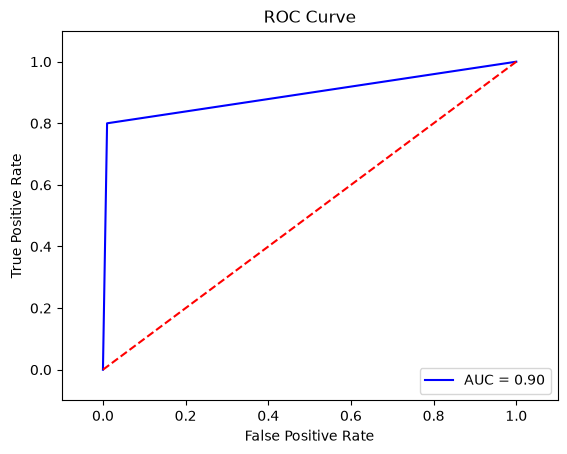

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn import metrics
from sklearn.metrics import roc_auc_score

# Let's get the labels of our test set; we will use these to evaluate our predictions
!tail -121 test_data/test-dataset.csv > test_data/test_dataset_sample_tail.csv
df_with_labels = pd.read_csv("test_data/test_dataset_sample_tail.csv")
test_labels = df_with_labels.iloc[:, 0]
labels = test_labels.to_numpy()

# Calculate accuracy
accuracy = sum(preds == labels) / len(labels)
print(f"Accuracy: {accuracy}")

# Calculate precision
precision = sum(preds[preds == 1] == labels[preds == 1]) / len(preds[preds == 1])
print(f"Precision: {precision}")

# Calculate recall
recall = sum(preds[preds == 1] == labels[preds == 1]) / len(labels[labels == 1])
print(f"Recall: {recall}")

# Calculate F1 score
f1_score = 2 * (precision * recall) / (precision + recall)
print(f"F1 Score: {f1_score}")

# Calculate AUC
auc = round(roc_auc_score(labels, preds), 4)
print("AUC is " + repr(auc))

fpr, tpr, _ = metrics.roc_curve(labels, preds)

plt.title("ROC Curve")
plt.plot(fpr, tpr, "b", label="AUC = %0.2f" % auc)
plt.legend(loc="lower right")
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.show()

### Next, we collect data for Variant2

In [13]:
predictions2 = ""
print(f"Sending test traffic to the endpoint {endpoint_name}. \nPlease wait...")
with open("test_data/test_sample_tail_input_cols.csv", "r") as f:
    for row in f:
        print(".", end="", flush=True)
        payload = row.rstrip("\n")
        # V3: target Variant2 via Endpoint.invoke(target_variant=...)
        response = endpoint.invoke(
            body=payload,
            content_type="text/csv",
            target_variant=variant2.variant_name,
        )
        predictions2 = ",".join([predictions2, response.body.read().decode("utf-8")])
        time.sleep(0.5)

# Convert to numpy array
pred_np2 = np.fromstring(predictions2[1:], sep=",")

# Convert to binary predictions
thresh = 0.5
preds2 = np.where(pred_np2 > threshold, 1, 0)

print("Done!")

Sending test traffic to the endpoint DEMO-xgb-churn-pred-2026-07-16-09-52-05. 
Please wait...
.

.

.

.

.

...

.

.

.

.

Done!


When we again check the traffic per variant, this time we see that the number of invocations only incremented for Variant2, because all invocations were targeted at that variant:

In [14]:
time.sleep(60)  # give metrics time to catch up
plot_endpoint_metrics()

No CloudWatch invocation metrics available yet (metrics can lag a few minutes).


,Variant1,Variant2


### Evaluating Variant2 

Accuracy: 0.9583333333333334
Precision: 0.8947368421052632
Recall: 0.85
F1 Score: 0.8717948717948718
AUC is 0.915


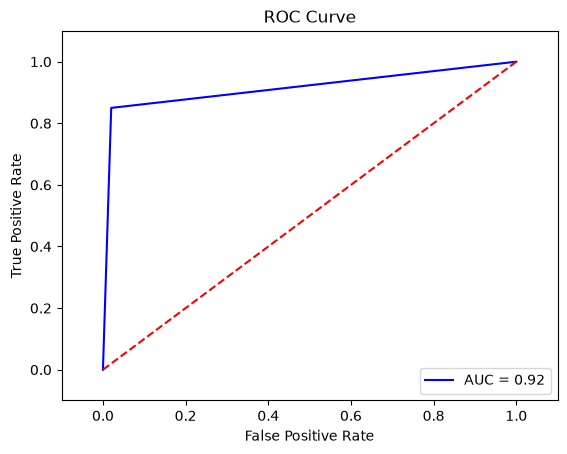

In [15]:
# Calculate accuracy
accuracy2 = sum(preds2 == labels) / len(labels)
print(f"Accuracy: {accuracy2}")

# Calculate precision
precision2 = sum(preds2[preds2 == 1] == labels[preds2 == 1]) / len(preds2[preds2 == 1])
print(f"Precision: {precision2}")

# Calculate recall
recall2 = sum(preds2[preds2 == 1] == labels[preds2 == 1]) / len(labels[labels == 1])
print(f"Recall: {recall2}")

# Calculate F1 score
f1_score2 = 2 * (precision2 * recall2) / (precision2 + recall2)
print(f"F1 Score: {f1_score2}")

auc2 = round(roc_auc_score(labels, preds2), 4)
print("AUC is " + repr(auc2))

fpr2, tpr2, _ = metrics.roc_curve(labels, preds2)

plt.title("ROC Curve")
plt.plot(fpr2, tpr2, "b", label="AUC = %0.2f" % auc2)
plt.legend(loc="lower right")
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.ylabel("True Positive Rate")
plt.xlabel("False Positive Rate")
plt.show()

We see that Variant2 is performing better for most of our defined metrics, so this is the one we’re likely to choose to dial up in production.

## Step 4: Dialing up our chosen variant in production

Now that we have determined Variant2 to be better as compared to Variant1, we will shift more traffic to it. 

We can continue to use TargetVariant to continue invoking a chosen variant. A simpler approach is to update the weights assigned to each variant using UpdateEndpointWeightsAndCapacities. This changes the traffic distribution to your production variants without requiring updates to your endpoint. 

Recall our variant weights are as follows:

In [16]:
# V3: refresh the Endpoint resource and read current weights from production_variants
endpoint.refresh()
{pv.variant_name: pv.current_weight for pv in endpoint.production_variants}

{'Variant1': 1.0, 'Variant2': 1.0}

We'll first write a method to easily invoke our endpoint (a copy of what we had been previously doing):

In [17]:
def invoke_endpoint_for_two_minutes():
    with open("test_data/test-dataset-input-cols.csv", "r") as f:
        for row in f:
            print(".", end="", flush=True)
            payload = row.rstrip("\n")
            # V3: Endpoint.invoke replaces boto3 sm_runtime.invoke_endpoint
            response = endpoint.invoke(body=payload, content_type="text/csv")
            response.body.read()
            time.sleep(1)

We invoke our endpoint for a bit, to show the even split in invocations:

In [18]:
invocation_start_time = datetime.now()
invoke_endpoint_for_two_minutes()
time.sleep(20)  # give metrics time to catch up
plot_endpoint_metrics(invocation_start_time)

.

.

.

.

.

...

.

.

.

No CloudWatch invocation metrics available yet (metrics can lag a few minutes).


,Variant1,Variant2


Now let us shift 75% of the traffic to Variant2 by assigning new weights to each variant using UpdateEndpointWeightsAndCapacities. Amazon SageMaker will now send 75% of the inference requests to Variant2 and remaining 25% of requests to Variant1. 

In [19]:
# V3: shift traffic with Endpoint.update_weights_and_capacities + DesiredWeightAndCapacity
from sagemaker.core.shapes import DesiredWeightAndCapacity

endpoint.update_weights_and_capacities(
    [
        DesiredWeightAndCapacity(desired_weight=25, variant_name=variant1.variant_name),
        DesiredWeightAndCapacity(desired_weight=75, variant_name=variant2.variant_name),
    ]
)

In [20]:
# V3: wait for the endpoint to return to InService, then read current weights
endpoint.wait_for_status("InService")
print("Done")

endpoint.refresh()
{pv.variant_name: pv.current_weight for pv in endpoint.production_variants}

Output()

[07/16/26 10:07:54] INFO     Final Resource Status: InService                                    ]8;id=8458154;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=8458155;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10484\10484]8;;\

Done


{'Variant1': 25.0, 'Variant2': 75.0}

Now let's check how that has impacted invocation metrics:

In [21]:
invoke_endpoint_for_two_minutes()
time.sleep(20)  # give metrics time to catch up
plot_endpoint_metrics(invocation_start_time)

.

.

.

.

.

...

.

.

.

No CloudWatch invocation metrics available yet (metrics can lag a few minutes).


,Variant1,Variant2


We can continue to monitor our metrics and when we're satisfied with a variant's performance, we can route 100% of the traffic over the variant. We used UpdateEndpointWeightsAndCapacities to update the traffic assignments for the variants. The weight for Variant1 is set to 0 and the weight for Variant2 is set to 1. Therefore, Amazon SageMaker will send 100% of all inference requests to Variant2.

In [22]:
# Route 100% of traffic to Variant2 by setting Variant1's weight to 0.
#
# NOTE: this step falls back to the boto3 SageMaker client instead of
# Endpoint.update_weights_and_capacities. The sagemaker-core serializer
# (_serialize_shape in sagemaker/core/utils/utils.py) drops falsy field
# values via `if serialize_result := serialize(v):`, so a DesiredWeight of
# 0 is silently omitted and the API rejects the update with
# "should be updated only with desired weight or desired instance count".
# A non-zero weight (e.g. the 25/75 split above) works fine via the V3 API.
sm_boto3 = boto3.client("sagemaker", region_name=region)
sm_boto3.update_endpoint_weights_and_capacities(
    EndpointName=endpoint_name,
    DesiredWeightsAndCapacities=[
        {"DesiredWeight": 0, "VariantName": variant1.variant_name},
        {"DesiredWeight": 1, "VariantName": variant2.variant_name},
    ],
)
print("Waiting for update to complete")
endpoint.wait_for_status("InService")
print("Done")

endpoint.refresh()
{pv.variant_name: pv.current_weight for pv in endpoint.production_variants}

[07/16/26 10:13:54] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=8459966;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=8459967;file:///Users/lucasjia/pysdk/pysdk-workspace/.v3test-venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

Output()

Waiting for update to complete


[07/16/26 10:15:11] INFO     Final Resource Status: InService                                    ]8;id=8459972;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=8459973;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10484\10484]8;;\

Done


{'Variant1': 0.0, 'Variant2': 1.0}

In [23]:
invoke_endpoint_for_two_minutes()
time.sleep(20)  # give metrics time to catch up
plot_endpoint_metrics(invocation_start_time)

.

.

.

.

.

...

.

.

.

No CloudWatch invocation metrics available yet (metrics can lag a few minutes).


,Variant1,Variant2


The Amazon CloudWatch metrics for the total invocations for each variant below shows us that all inference requests are being processed by Variant2 and there are no inference requests processed by Variant1.

You can now safely update your endpoint and delete Variant1 from your endpoint. You can also continue testing new models in production by adding new variants to your endpoint and following steps 2 - 4. 

## Delete the endpoint

If you do not plan to use this endpoint further, you should delete the endpoint to avoid incurring additional charges.

In [24]:
# V3: delete the Endpoint, then its EndpointConfig and the two Models
# (V3 creates these as separate resources, so clean them up separately)
endpoint.delete()
try:
    EndpointConfig.get(endpoint_config_name).delete()
except Exception as e:
    print("EndpointConfig cleanup:", e)
for m in (model, model2):
    try:
        m.delete()
    except Exception as e:
        print("Model cleanup:", e)

[07/16/26 10:21:12] INFO     Deleting Endpoint - DEMO-xgb-churn-pred-2026-07-16-09-52-05         ]8;id=8461779;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=8461780;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#10428\10428]8;;\

                    INFO     Deleting EndpointConfig - DEMO-xgb-churn-pred-2026-07-16-09-52-05   ]8;id=8461786;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=8461787;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#11220\11220]8;;\

                    INFO     Deleting Model - DEMO-xgb-churn-pred-2026-07-16-09-52-02            ]8;id=8461793;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=8461794;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20740\20740]8;;\

[07/16/26 10:21:13] INFO     Deleting Model - DEMO-xgb-churn-pred2-2026-07-16-09-52-02           ]8;id=8461799;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py\resources.py]8;;\:]8;id=8461800;file:///Users/lucasjia/pysdk/pysdk-workspace/sagemaker-python-sdk-lucas/sagemaker-core/src/sagemaker/core/resources.py#20740\20740]8;;\

## Notebook CI Test Results

This notebook was tested in multiple regions. The test results are as follows, except for us-west-2 which is shown at the top of the notebook.

![This us-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-1/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This us-east-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-east-2/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This us-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/us-west-1/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This ca-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ca-central-1/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This sa-east-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/sa-east-1/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This eu-west-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-1/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This eu-west-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-2/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This eu-west-3 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-west-3/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This eu-central-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-central-1/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This eu-north-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/eu-north-1/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This ap-southeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-1/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This ap-southeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-southeast-2/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This ap-northeast-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-1/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This ap-northeast-2 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-northeast-2/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)

![This ap-south-1 badge failed to load. Check your device's internet connectivity, otherwise the service is currently unavailable](https://prod.us-west-2.tcx-beacon.docs.aws.dev/sagemaker-nb/ap-south-1/deploy_and_monitor|sm-a_b_testing|sm-a_b_testing.ipynb)
